## **Analysis of Populism Dimensions in the EP**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load classified datasets

elite = pd.read_csv('../data/ep_speeches_anti_elitism.csv')
people = pd.read_csv('../data/ep_speeches_people_centrism.csv')
populism = pd.read_csv('../data/ep_speeches_populism.csv')

In [3]:
len(elite)

4055401

In [4]:
len(people)

4055401

In [5]:
len(populism)

4055401

In [6]:
# Merge into fully classified ep dataset

shared_cols = elite.columns.intersection(people.columns).tolist()
ep = pd.merge(elite, people, on=shared_cols, how='left')
ep.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,prob_non_elitism,prob_anti_elitism,anti_elitism_binary,prob_non_centrism,prob_people_centrism,people_centrism_binary
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Madam President, dear colleagues!",0.945230,0.054770,0,0.735462,0.264538,0
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,Politics must not be for sale.,0.782590,0.217410,0,0.913186,0.086814,0
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,It cannot be that political decisions in this ...,0.235034,0.764966,1,0.880167,0.119833,0
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Whether Qatar, Russia, or China – especially w...",0.918710,0.081290,0,0.979357,0.020643,0
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Even below the threshold of criminal law, belo...",0.885458,0.114542,0,0.982642,0.017358,0


In [7]:
# Merge into fully classified ep dataset

shared_cols = ep.columns.intersection(populism.columns).tolist()
ep = pd.merge(ep, populism, on=shared_cols, how='left')
ep.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,prob_non_elitism,prob_anti_elitism,anti_elitism_binary,prob_non_centrism,prob_people_centrism,people_centrism_binary,prob_non_populism,prob_populism,populism_binary
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Madam President, dear colleagues!",0.945230,0.054770,0,0.735462,0.264538,0,0.995385,0.004615,0
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,Politics must not be for sale.,0.782590,0.217410,0,0.913186,0.086814,0,0.989144,0.010856,0
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,It cannot be that political decisions in this ...,0.235034,0.764966,1,0.880167,0.119833,0,0.969885,0.030115,0
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Whether Qatar, Russia, or China – especially w...",0.918710,0.081290,0,0.979357,0.020643,0,0.993131,0.006869,0
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Even below the threshold of criminal law, belo...",0.885458,0.114542,0,0.982642,0.017358,0,0.993622,0.006378,0


In [8]:
# Save full ep dataset 
ep.to_csv('../data/ep_speeches_classified_total.csv', index=False)

In [3]:
# Load full ep dataset
ep = pd.read_csv('../data/ep_speeches_classified_total.csv')
ep.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,prob_non_elitism,prob_anti_elitism,anti_elitism_binary,prob_non_centrism,prob_people_centrism,people_centrism_binary,prob_non_populism,prob_populism,populism_binary
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Madam President, dear colleagues!",0.945230,0.054770,0,0.735462,0.264538,0,0.995385,0.004615,0
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,Politics must not be for sale.,0.782590,0.217410,0,0.913186,0.086814,0,0.989144,0.010856,0
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,It cannot be that political decisions in this ...,0.235034,0.764966,1,0.880167,0.119833,0,0.969885,0.030115,0
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Whether Qatar, Russia, or China – especially w...",0.918710,0.081290,0,0.979357,0.020643,0,0.993131,0.006869,0
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Even below the threshold of criminal law, belo...",0.885458,0.114542,0,0.982642,0.017358,0,0.993622,0.006378,0


## **Metrics & Visuals**

#### Populism as combined indicator 



In [4]:
# Create column of anti-elitism & people-centrism combined 

ep['populism_combined'] = ((ep['anti_elitism_binary'] == 1) & (ep['people_centrism_binary'] == 1)).astype(int)

In [5]:
ep['populism_combined'].value_counts()

populism_combined
0    4017010
1      38391
Name: count, dtype: int64

In [6]:
ep['populism_binary'].value_counts()

populism_binary
0    3991230
1      64171
Name: count, dtype: int64

### **Populism Distribution across Parties**
##### Sentences (according to each single dimension) by party (normalised)

In [7]:
ep['party'].unique()

array(['Greens/EFA', 'PPE', 'S&D', 'Renew', 'ID', 'The Left', 'ECR', 'NI',
       '-', 'GUE/NGL', 'ALDE', 'EFDD', 'ENF', 'UEN', 'IND/DEM'],
      dtype=object)

In [8]:
# Adapt party names to stretch across all periods

ep['party'] = ep['party'].replace({
    'GUE/NGL': 'The Left',
    'ALDE': 'Renew',
    'ENF': 'ID',
})

In [9]:
# References of anti-elitism by party normalised by total sentences per party

party_stats = ep.groupby('party').agg(
    anti_elitism_count=('anti_elitism_binary', 'sum'),
    people_centrism_count=('people_centrism_binary', 'sum'),
    populism_count=('populism_binary', 'sum'),
    populism_combined_count=('populism_combined', 'sum'),
    total_sentences=('sentence', 'count')
)
party_stats['anti_elitism_normalised'] = party_stats['anti_elitism_count'] / party_stats['total_sentences']*100
party_stats['people_centrism_normalised'] = party_stats['people_centrism_count'] / party_stats['total_sentences']*100
party_stats['populism_normalised'] = party_stats['populism_count'] / party_stats['total_sentences']*100
party_stats['populism_combined_normalised'] = party_stats['populism_combined_count'] / party_stats['total_sentences']*100

In [10]:
# Set colour palette for individual parties

line_palette = sns.color_palette(n_colors=len(ep['party'].unique()))

#### Anti-elitism

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_88532/4042382784.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=party_stats.index, y=party_stats['anti_elitism_normalised'], palette=line_palette)


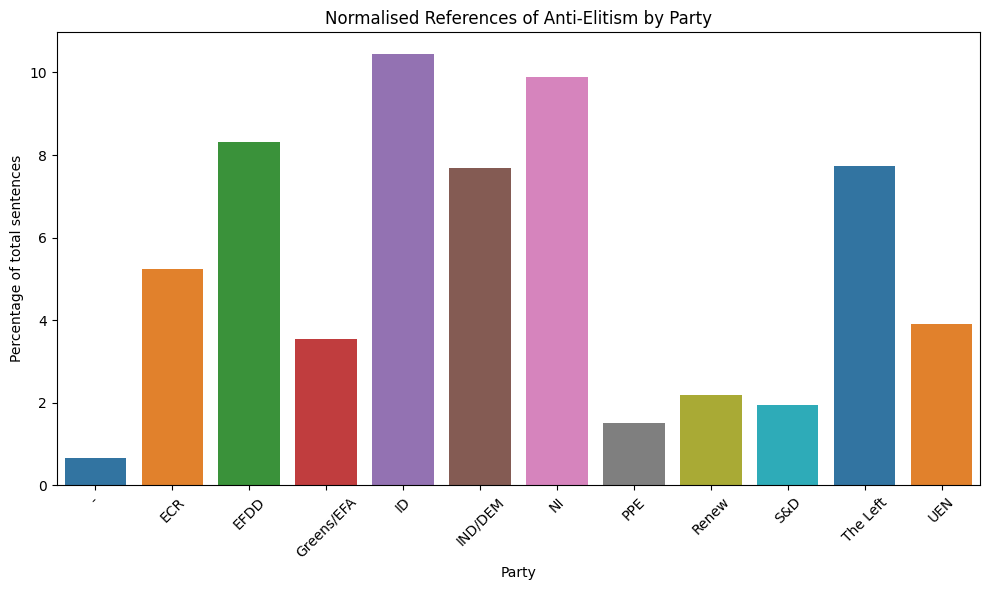

In [11]:
# Visualise references of anti-elitism by party (normalised)

plt.figure(figsize=(10, 6))
sns.barplot(x=party_stats.index, y=party_stats['anti_elitism_normalised'], palette=line_palette)
plt.title('Normalised References of Anti-Elitism by Party')
plt.xlabel('Party')
plt.ylabel('Percentage of total sentences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/normalised_anti_elitism_by_party.png', dpi=150, bbox_inches='tight')
plt.show()

#### People-centrism

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_88532/3374624608.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=party_stats.index, y=party_stats['people_centrism_normalised'], palette=line_palette)


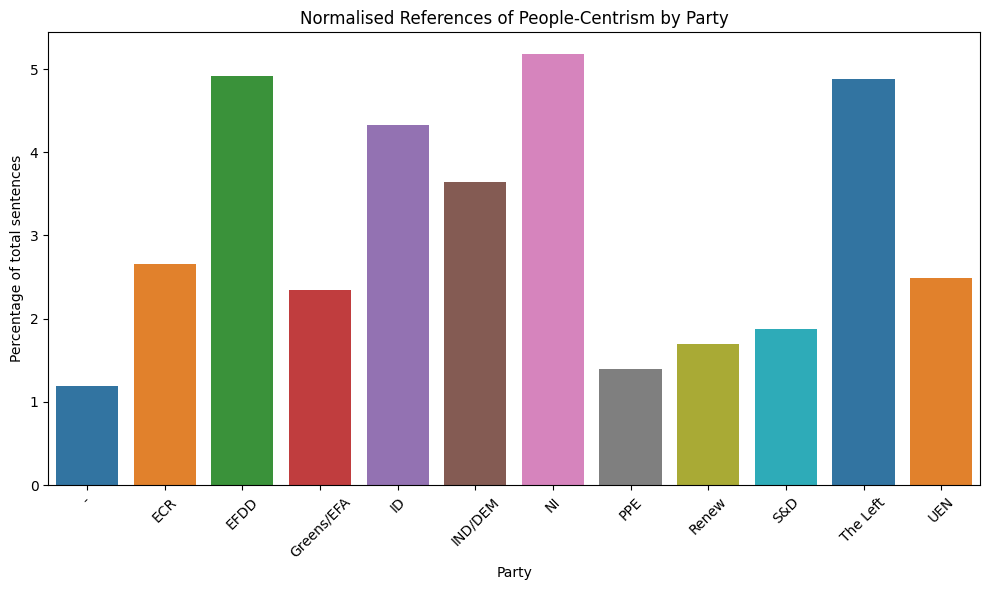

In [12]:
# Visualise references of people-centrism by party (normalised)

plt.figure(figsize=(10, 6))
sns.barplot(x=party_stats.index, y=party_stats['people_centrism_normalised'], palette=line_palette)
plt.title('Normalised References of People-Centrism by Party')
plt.xlabel('Party')
plt.ylabel('Percentage of total sentences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/normalised_people_centrism_by_party.png', dpi=150, bbox_inches='tight')
plt.show()

#### Populism

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_88532/674806753.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=party_stats.index, y=party_stats['populism_normalised'], palette=line_palette)


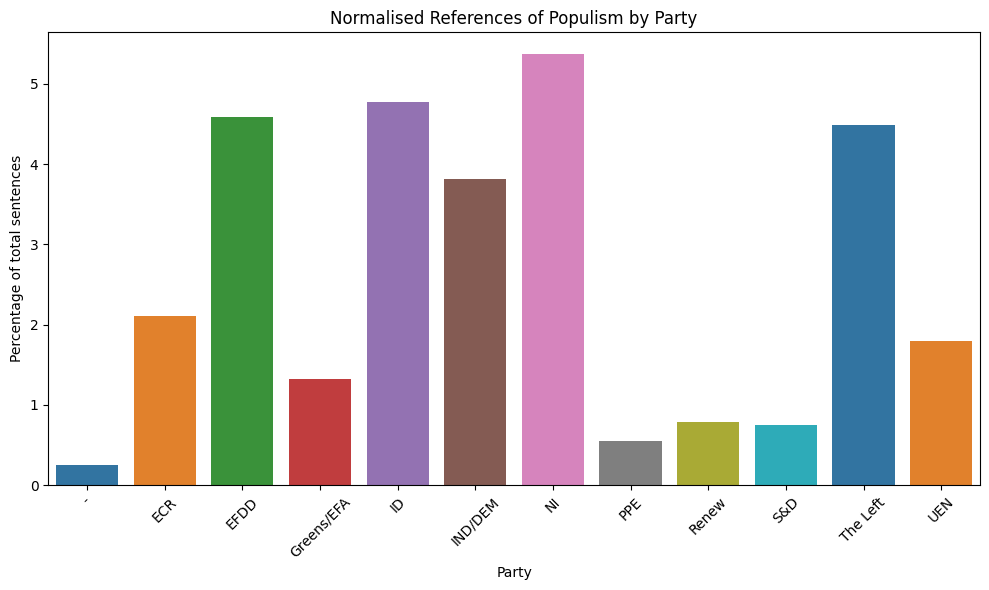

In [13]:
# Visualise references of people-centrism by party (normalised)

plt.figure(figsize=(10, 6))
sns.barplot(x=party_stats.index, y=party_stats['populism_normalised'], palette=line_palette)
plt.title('Normalised References of Populism by Party')
plt.xlabel('Party')
plt.ylabel('Percentage of total sentences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/normalised_populism_by_party.png', dpi=150, bbox_inches='tight')
plt.show()

#### Populism combined

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_88532/3342484288.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=party_stats.index, y=party_stats['populism_combined_normalised'], palette=line_palette)


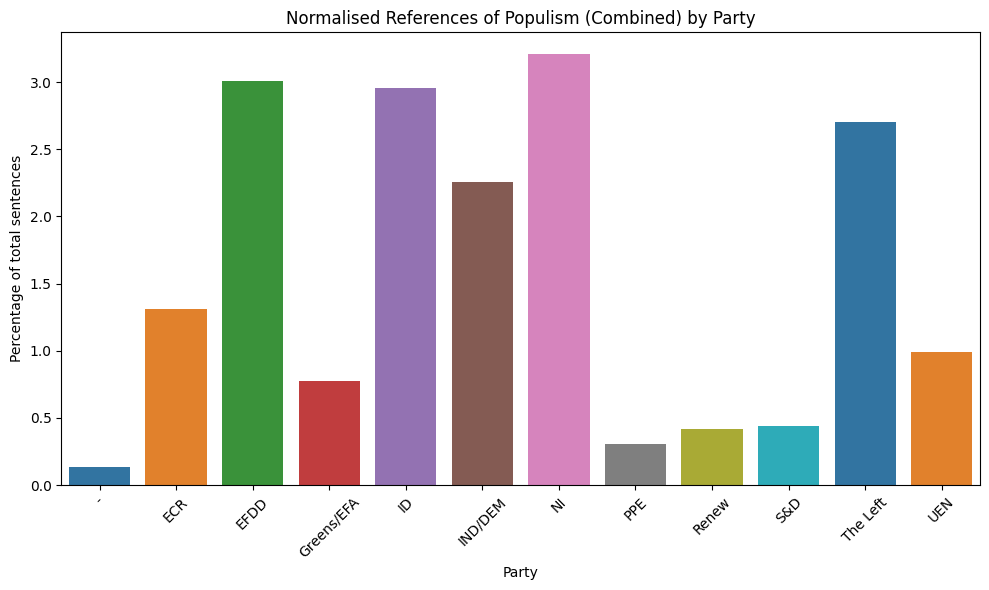

In [14]:
# Visualise references of people-centrism by party (normalised)

plt.figure(figsize=(10, 6))
sns.barplot(x=party_stats.index, y=party_stats['populism_combined_normalised'], palette=line_palette)
plt.title('Normalised References of Populism (Combined) by Party')
plt.xlabel('Party')
plt.ylabel('Percentage of total sentences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/normalised_populism_combined_by_party.png', dpi=150, bbox_inches='tight')
plt.show()

### **Dimensions of Populism over Time**

In [20]:
dimensions = [
    ('anti_elitism_binary', 'Anti-Elitism', 'steelblue'),
    ('people_centrism_binary', 'People-Centrism', 'darkorange'),
    ('populism_binary', 'Populism', 'green'),
    ('populism_combined', 'Combined Populism', 'red')
]

#### Normalised Plots

In [60]:
# Total sentences per year for normalisation
year_totals = ep.groupby('year')['sentence'].count().reset_index()
year_totals.columns = ['year', 'total_sentences']

In [61]:
# Sum per year and normalise
dim_cols = [d[0] for d in dimensions]
over_time = ep.groupby('year')[dim_cols].sum().reset_index()
over_time = over_time.merge(year_totals, on='year')
for dim in dim_cols:
    over_time[dim] = (over_time[dim] / over_time['total_sentences']) * 100

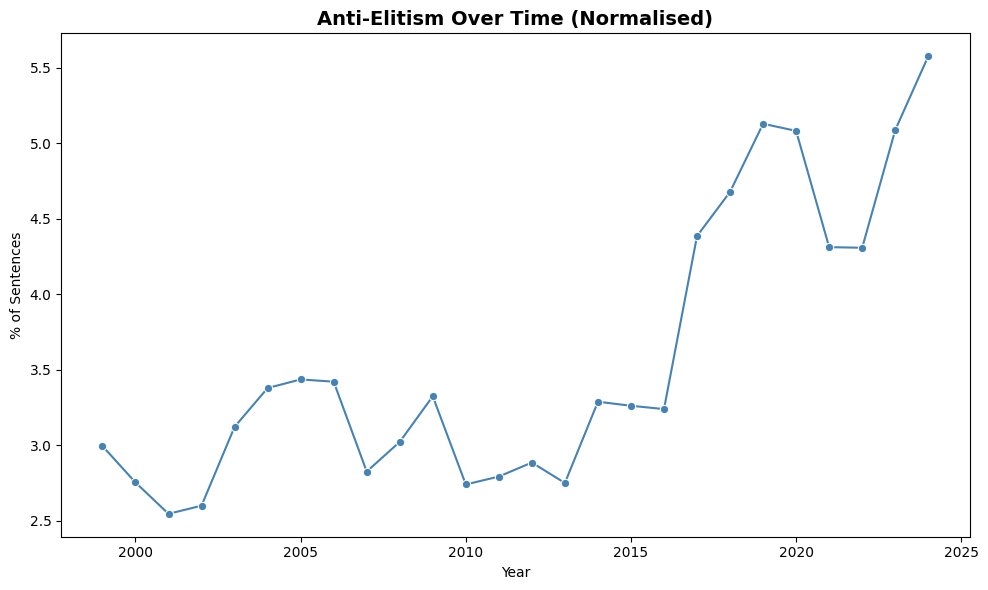

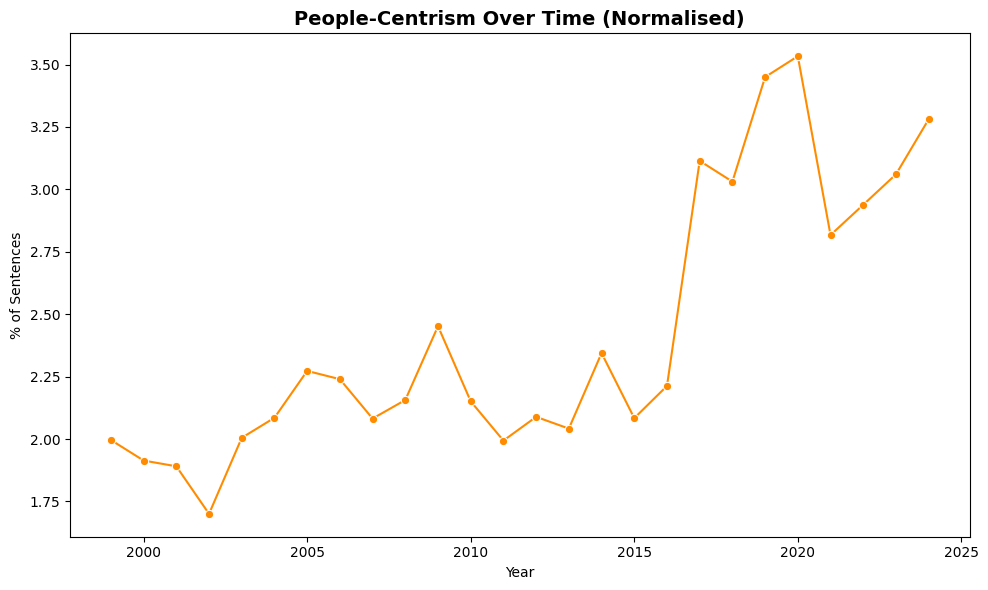

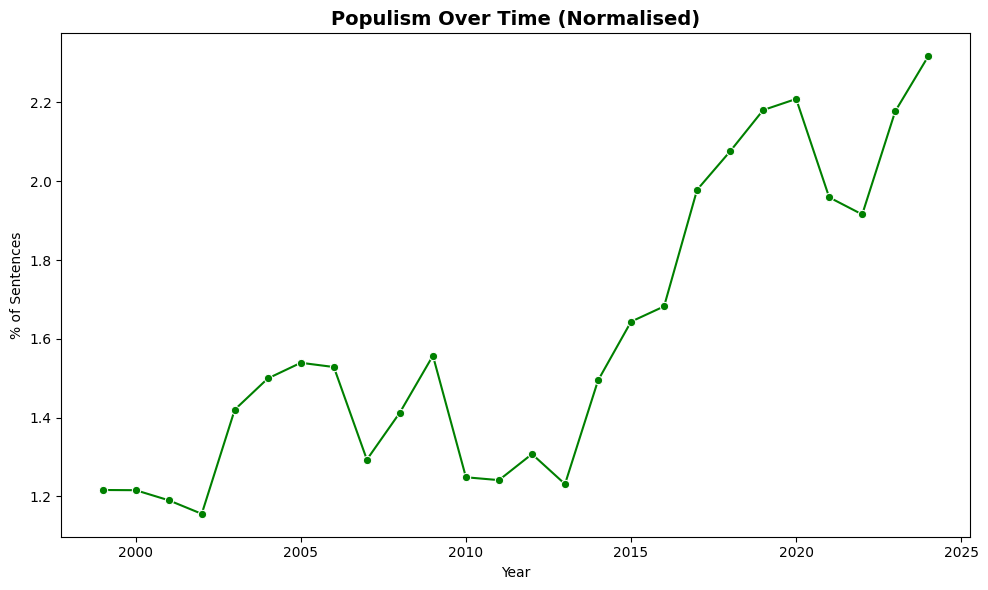

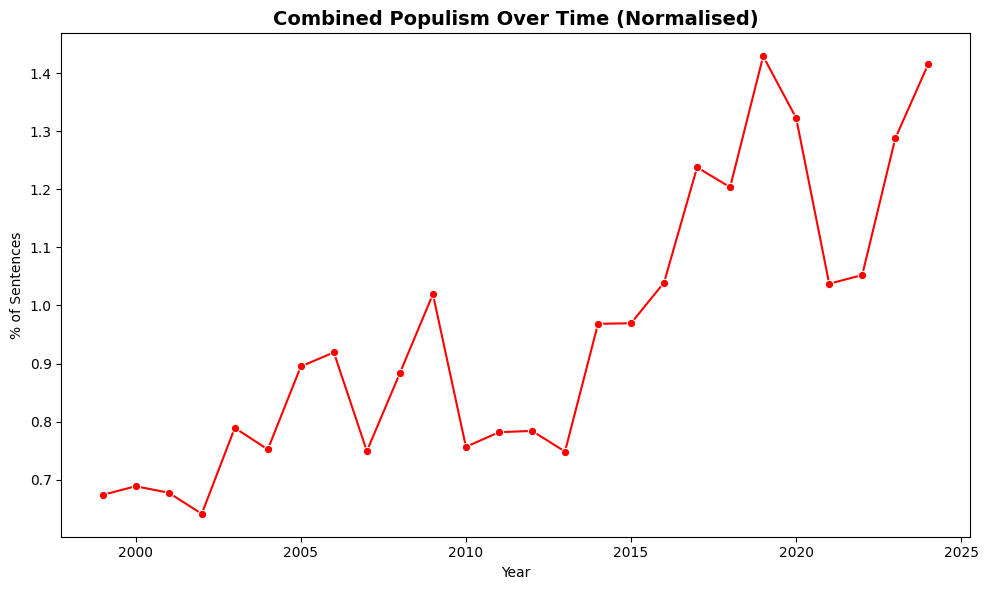

In [51]:
# Plot each dimension separately
for dim, title, color in dimensions:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(data=over_time, x='year', y=dim, marker='o', color=color, ax=ax)
    ax.set_title(f'{title} Over Time (Normalised)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('% of Sentences')
    plt.tight_layout()
    plt.savefig(f'../outputs/graphs/{title.lower().replace(" ", "_")}_over_time.png', dpi=150, bbox_inches='tight')
    plt.show()

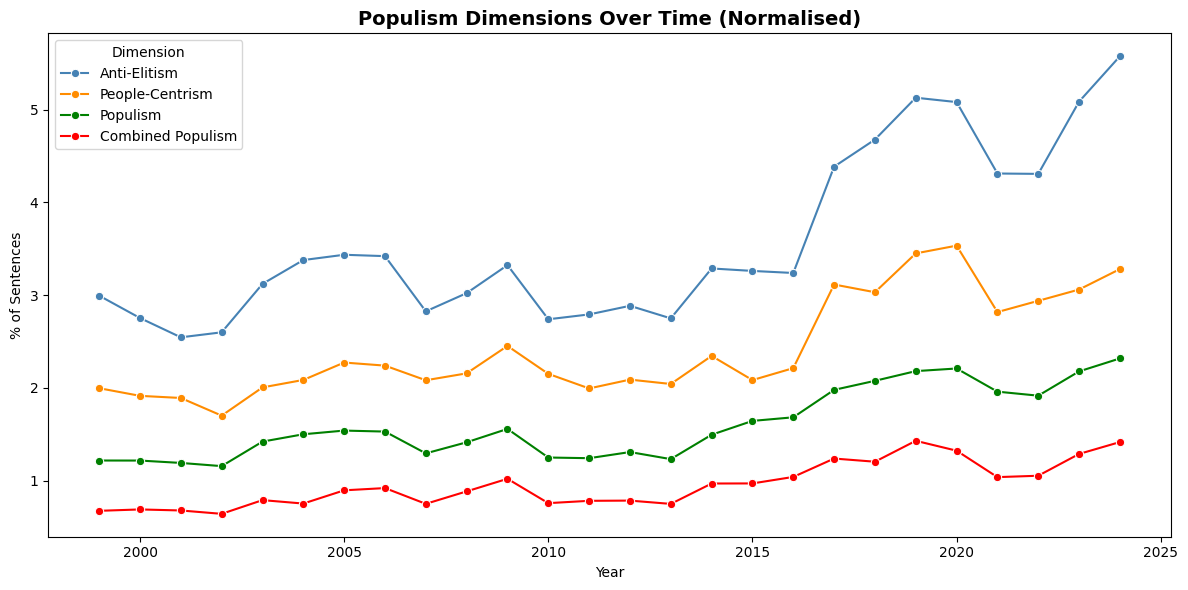

In [52]:
# Combined plot
fig, ax = plt.subplots(figsize=(12, 6))
for dim, title, color in dimensions:
    sns.lineplot(data=over_time, x='year', y=dim, marker='o', label=title, color=color, ax=ax)
ax.set_title('Populism Dimensions Over Time (Normalised)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% of Sentences')
ax.legend(title='Dimension')
plt.tight_layout()
plt.savefig('../outputs/graphs/combined_dimensions_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

#### All dimensions combined (not normalised)

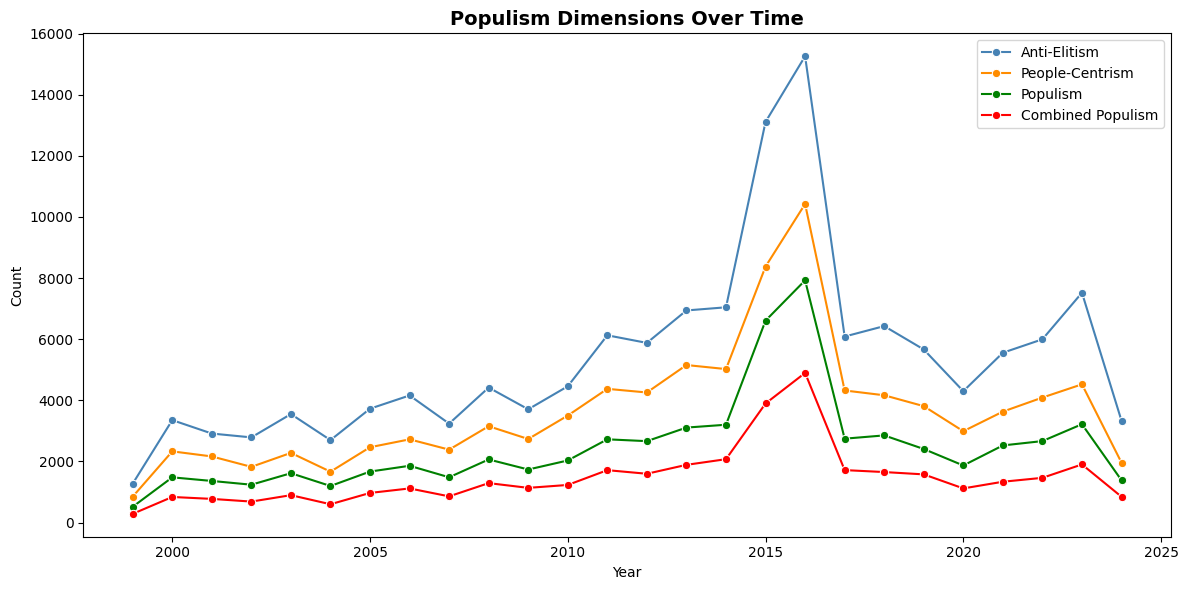

In [55]:
fig, ax = plt.subplots(figsize=(12, 6))

for dim, title, color in dimensions:
    over_time = ep.groupby('year')[dim].sum().reset_index()
    sns.lineplot(data=over_time, x='year', y=dim, marker='o', label=title, color=color, ax=ax)

ax.set_title('Populism Dimensions Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
#plt.savefig('../outputs/graphs/combined_dimensions_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

#### Add Election Years

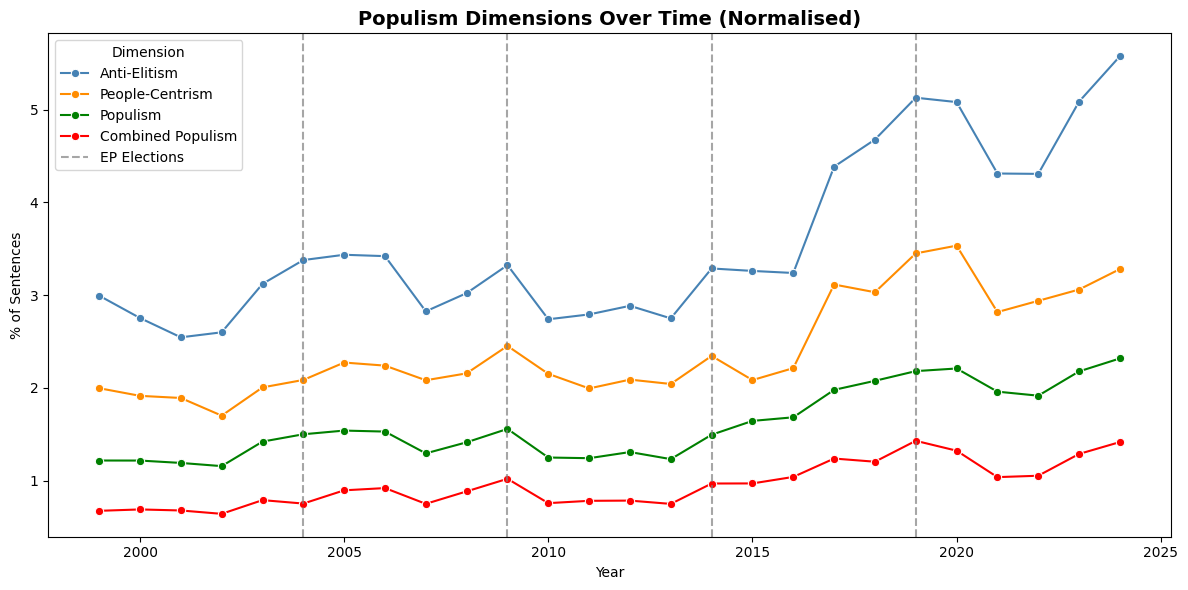

In [66]:
# Combined plot
fig, ax = plt.subplots(figsize=(12, 6))
for dim, title, color in dimensions:
    sns.lineplot(data=over_time, x='year', y=dim, marker='o', label=title, color=color, ax=ax)

election_years = [2004, 2009, 2014, 2019]
for year in election_years:
    ax.axvline(x=year, color='grey', linestyle='--', alpha=0.7, label='EP Elections ' if year == election_years[0] else '')

ax.set_title('Populism Dimensions Over Time (Normalised)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% of Sentences')
ax.legend(title='Dimension')
plt.tight_layout()
plt.savefig('../outputs/graphs/combined_dimensions_over_time_elections.png', dpi=150, bbox_inches='tight')
plt.show()

## **Indiviudal Metrics**

### Top populist speakers 

In [15]:
top20_populism = ep.groupby(['speaker', 'party'])['populism_combined'].sum().sort_values(ascending=False).head(20)
print(top20_populism)

speaker                 party   
João Ferreira           The Left    709
Κωνσταντίνος Παπαδάκης  NI          429
Jean-Luc Mélenchon      The Left    425
Σωτήριος Ζαριανόπουλος  NI          396
Ilda Figueiredo         The Left    343
Georgios Toussas        The Left    309
Inês Cristina Zuber     The Left    300
Bruno Gollnisch         NI          296
Νότης Μαριάς            ECR         255
Miguel Viegas           The Left    254
Dominique Bilde         ID          243
Athanasios Pafilis      The Left    222
Armonia Bordes          The Left    215
Λάμπρος Φουντούλης      NI          205
João Pimenta Lopes      The Left    199
Ελευθέριος Συναδινός    NI          191
Ангел Джамбазки         ECR         185
Efstratios Korakas      The Left    182
Andreas Mölzer          NI          177
Nigel Farage            EFDD        175
Name: populism_combined, dtype: int64


In [16]:
top20_elite = ep.groupby(['speaker', 'party'])['anti_elitism_binary'].sum().sort_values(ascending=False).head(20)
print(top20_elite)

speaker                  party     
João Ferreira            The Left      2036
Jean-Luc Mélenchon       The Left      1476
Bruno Gollnisch          NI            1150
Ilda Figueiredo          The Left       885
Inês Cristina Zuber      The Left       810
Ангел Джамбазки          ECR            795
Νότης Μαριάς             ECR            760
Nigel Farage             EFDD           740
Dominique Bilde          ID             738
Miguel Viegas            The Left       720
Mick Wallace             The Left       697
Σωτήριος Ζαριανόπουλος   NI             678
Κωνσταντίνος Παπαδάκης   NI             674
Clare Daly               The Left       649
Daniel Hannan            ECR            645
Philippe Lamberts        Greens/EFA     625
Andreas Mölzer           NI             607
Nicolas Bay              ID             583
Marie-Christine Vergiat  The Left       544
Gilles Lebreton          ID             496
Name: anti_elitism_binary, dtype: int64


In [17]:
top20_people = ep.groupby(['speaker', 'party'])['people_centrism_binary'].sum().sort_values(ascending=False).head(20)
print(top20_people)

speaker                 party     
João Ferreira           The Left      1108
Ilda Figueiredo         The Left       641
Κωνσταντίνος Παπαδάκης  NI             598
Σωτήριος Ζαριανόπουλος  NI             564
Jean-Luc Mélenchon      The Left       548
Inês Cristina Zuber     The Left       508
Νότης Μαριάς            ECR            468
Georgios Toussas        The Left       425
Bruno Gollnisch         NI             414
Miguel Viegas           The Left       389
Armonia Bordes          The Left       358
Jonathan Arnott         EFDD           336
Philippe Lamberts       Greens/EFA     335
Andreas Mölzer          NI             330
Ангел Джамбазки         ECR            321
Dominique Bilde         ID             312
Athanasios Pafilis      The Left       312
João Pimenta Lopes      The Left       309
Paul Murphy             The Left       303
Clare Daly              The Left       295
Name: people_centrism_binary, dtype: int64


In [18]:
speaker_stats = ep.groupby(['speaker', 'party']).agg(
    populism_count=('populism_combined', 'sum'),
    total_sentences=('sentence', 'count')
)
speaker_stats['normalised'] = (speaker_stats['populism_count'] / speaker_stats['total_sentences']) * 100
top20 = speaker_stats[speaker_stats['total_sentences'] >= 50].sort_values('normalised', ascending=False).head(20)
top20.head(20)

,,populism_count,total_sentences,normalised
speaker,party,,,
Γεώργιος Τούσσας,The Left,76,299,25.418060
Charalampos Angourakis,The Left,157,733,21.418827
Georgios Toussas,The Left,309,1499,20.613742
Florian Philippot,EFDD,18,89,20.224719
Claire Fox,NI,43,213,20.187793
Χαράλαμπος Αγγουράκης,The Left,89,442,20.135747
Κωνσταντίνος Παπαδάκης,NI,429,2157,19.888734
Henrik Overgaard Nielsen,NI,10,51,19.607843
Σωτήριος Ζαριανόπουλος,NI,396,2188,18.098720


### Populist Dimensions per Party per Period 

In [21]:
# Total sentences per period-party
total_sentences_pp = ep.groupby(['period', 'party']).size().reset_index(name='total_sentences')

party_period = total_sentences_pp.copy()

# Add normalised share for each dimension
for dim_col, dim_name, *_ in dimensions:
    populist_sentences = ep.groupby(['period', 'party'])[dim_col].sum().reset_index(name=f'{dim_name}_count')
    party_period = pd.merge(party_period, populist_sentences, on=['period', 'party'])
    party_period[f'{dim_name}_share'] = (party_period[f'{dim_name}_count'] / party_period['total_sentences']) * 100

print(party_period)

    period       party  total_sentences  Anti-Elitism_count  \
0        5           -            40308                 156   
1        5  Greens/EFA            51556                1492   
2        5     IND/DEM            20433                1130   
3        5          NI            17639                1240   
4        5         PPE           163629                3254   
5        5       Renew            46913                 866   
6        5         S&D           129536                2534   
7        5    The Left            54033                3465   
8        5         UEN            24372                1143   
9        6           -            43935                 231   
10       6  Greens/EFA            35596                1274   
11       6     IND/DEM            30603                2796   
12       6          NI            26064                2740   
13       6         PPE           182399                3495   
14       6       Renew            62685                

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_88532/1004670475.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Period')
/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_88532/1004670475.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Period')
/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_88532/1004670475.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Period')
/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_88532/1004670475.py:13: UserWarning: No artists with labels found to put in legend.  Note that art

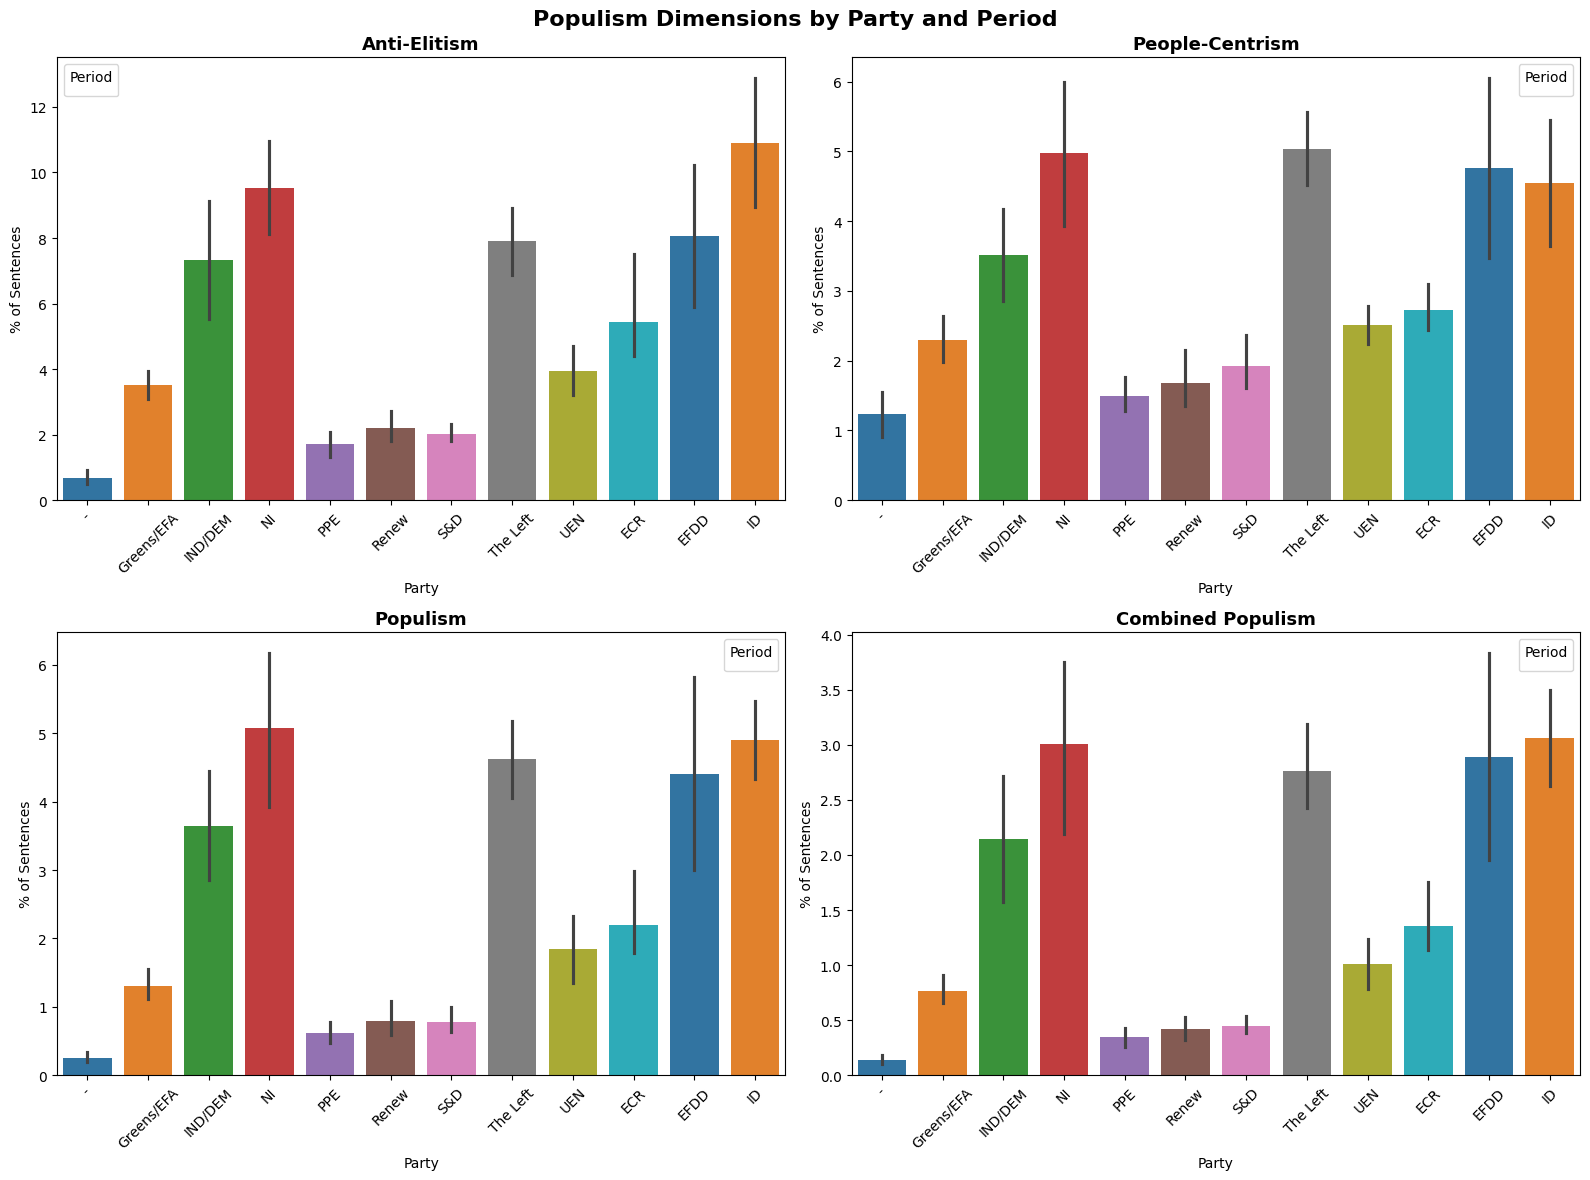

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for (dim_col, dim_name, *_), ax in zip(dimensions[:4], axes.flatten()):
    share_col = f'{dim_name}_share'
    
    sns.barplot(data=party_period, x='party', y=share_col, hue='party', 
                palette=line_palette, ax=ax)
    
    ax.set_title(dim_name.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Party')
    ax.set_ylabel('% of Sentences')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Period')

plt.suptitle('Populism Dimensions by Party and Period', fontsize=16, fontweight='bold')
plt.tight_layout()
#plt.savefig('../outputs/graphs/dimensions_party_period.png', dpi=150, bbox_inches='tight')
plt.show()

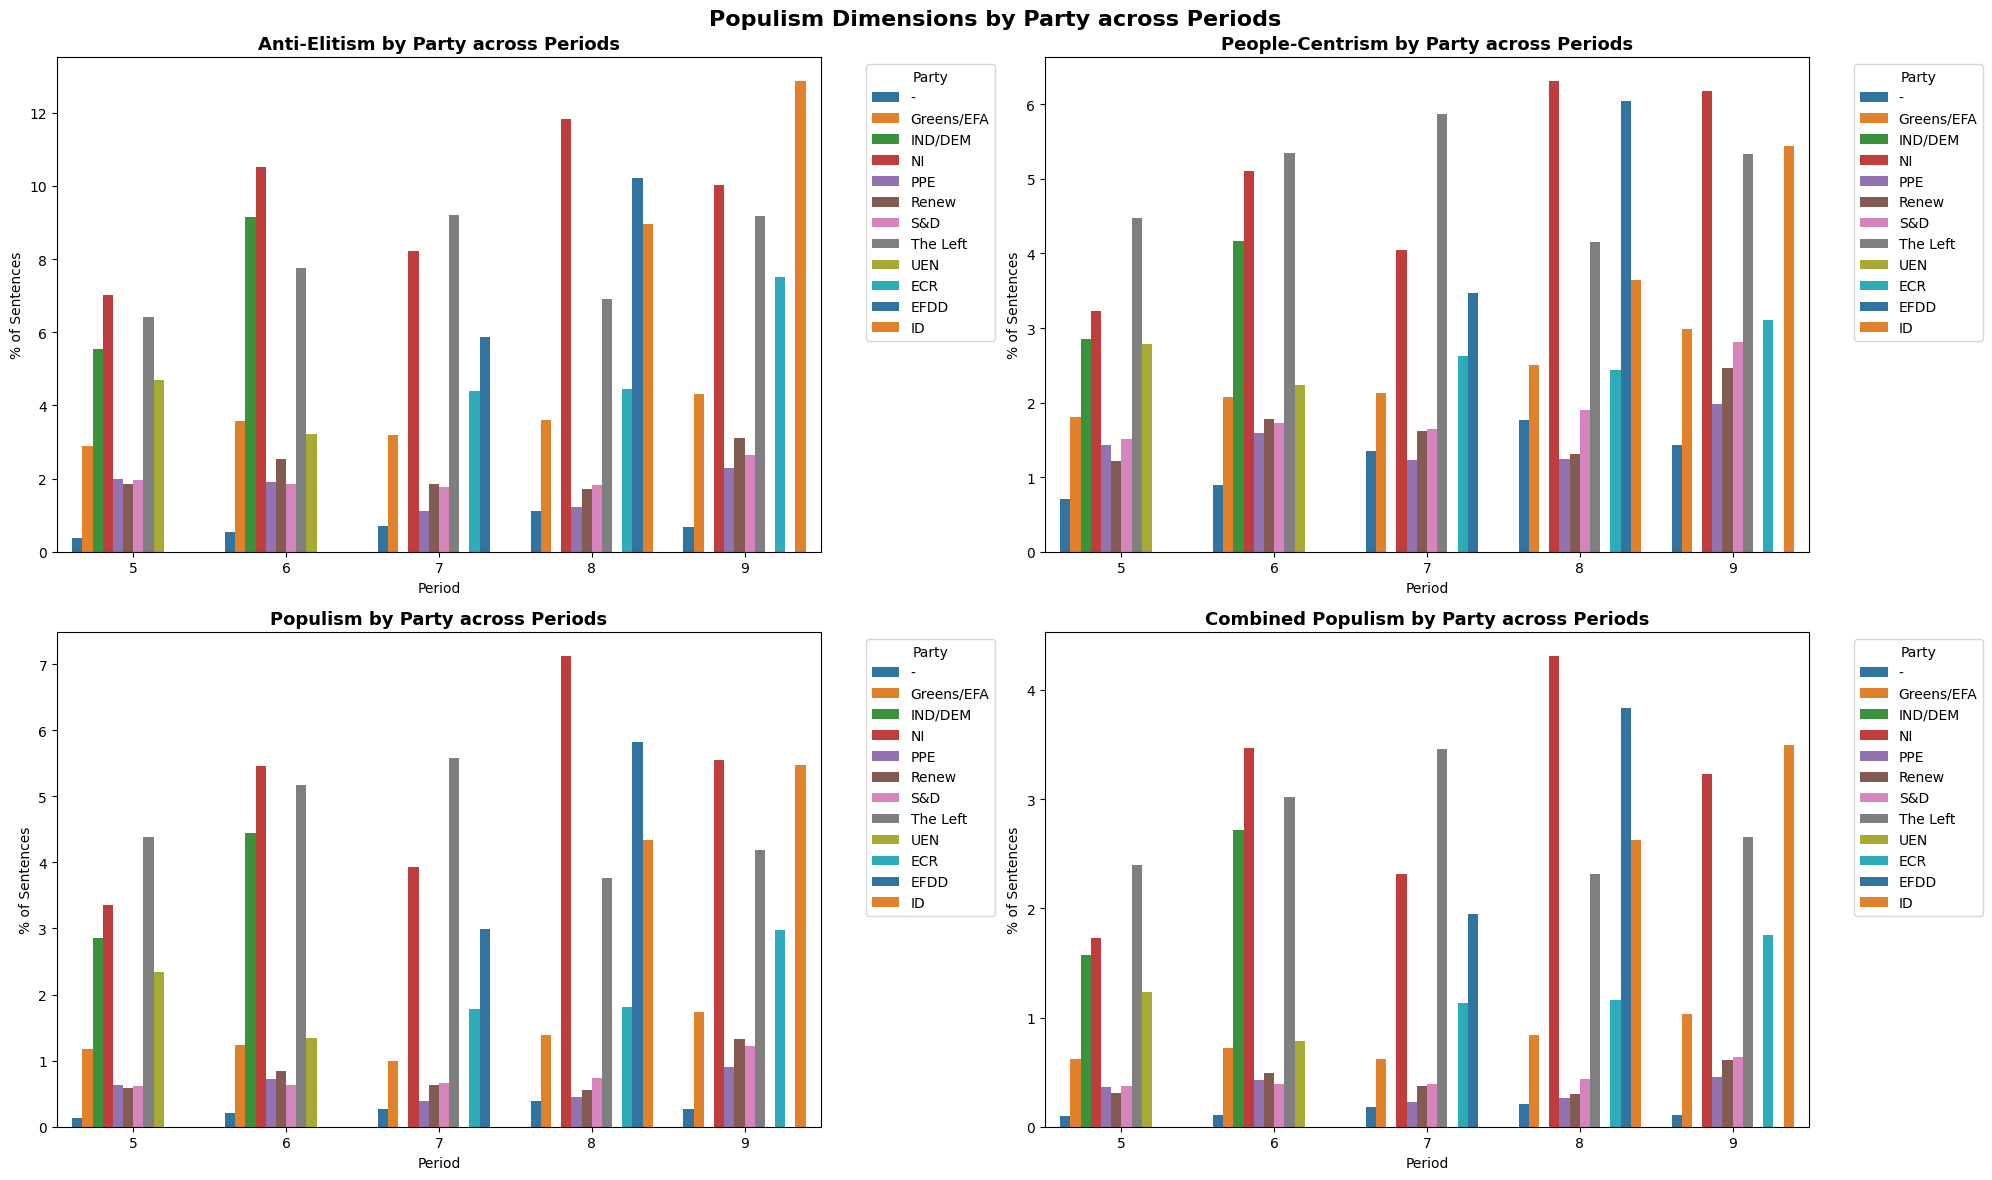

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

for (dim_col, dim_name, *_), ax in zip(dimensions[:4], axes.flatten()):
    share_col = f'{dim_name}_share'
    
    sns.barplot(
        data=party_period,
        x='period',
        y=share_col,
        hue='party',
        palette=line_palette,
        ax=ax
    )
    ax.set_title(f'{dim_name.replace("_", " ").title()} by Party across Periods', fontsize=13, fontweight='bold')
    ax.set_ylabel('% of Sentences')
    ax.set_xlabel('Period')
    ax.legend(title='Party', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Populism Dimensions by Party across Periods', fontsize=16, fontweight='bold')
plt.tight_layout()
#plt.savefig('../outputs/bar_charts/dimensions_party_period.png', dpi=300, bbox_inches='tight')
plt.show()

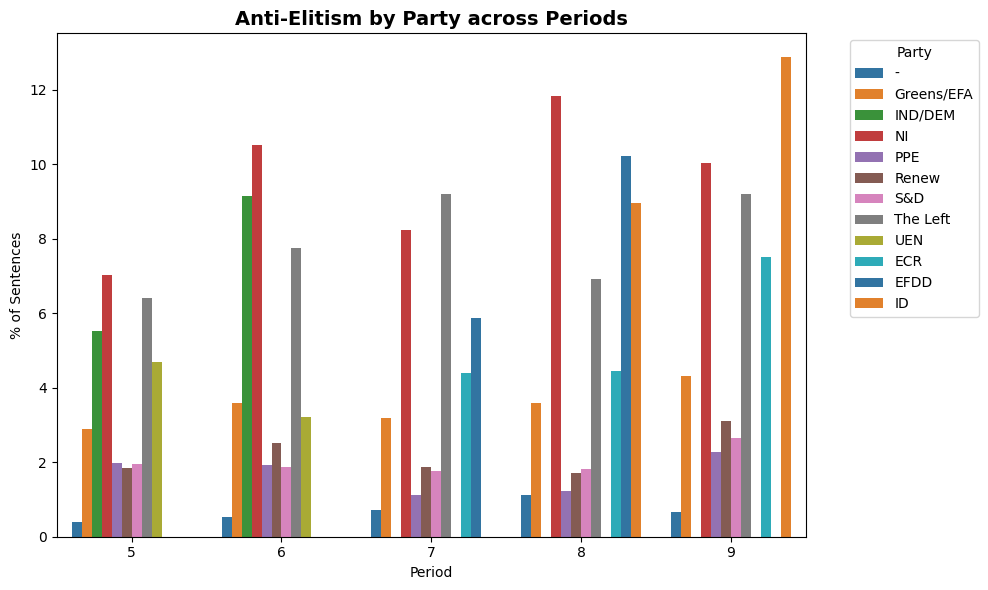

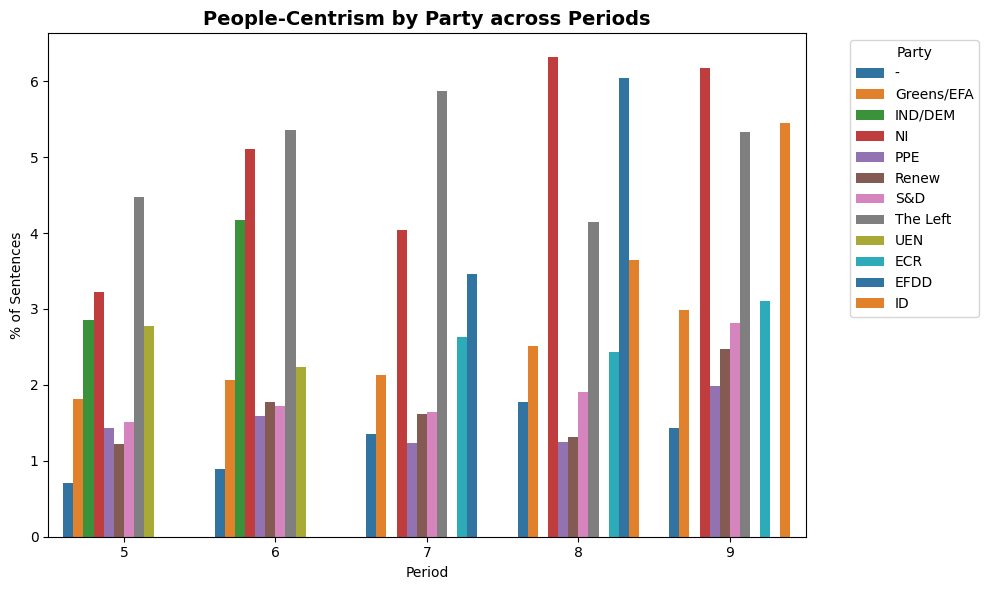

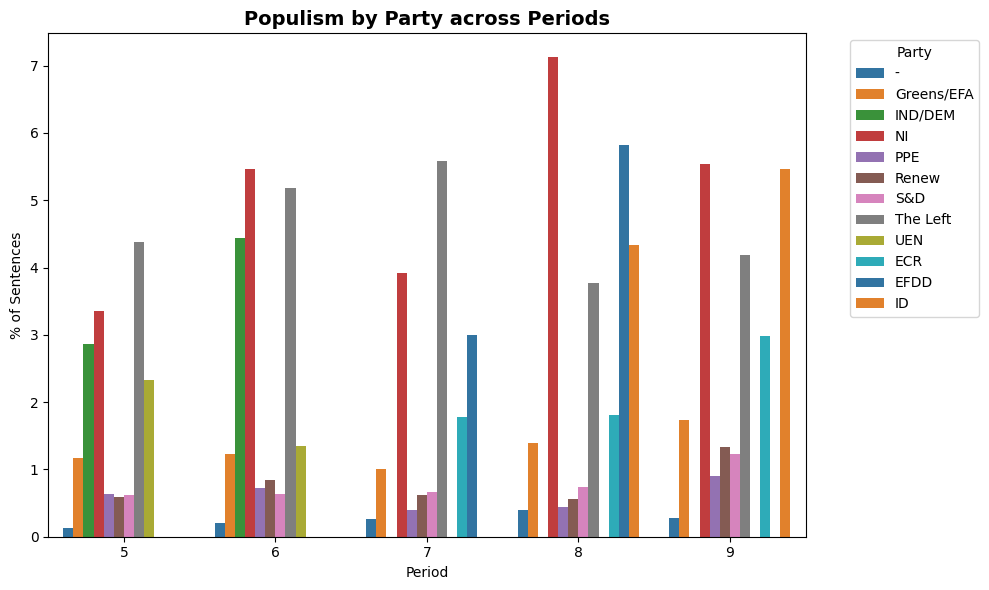

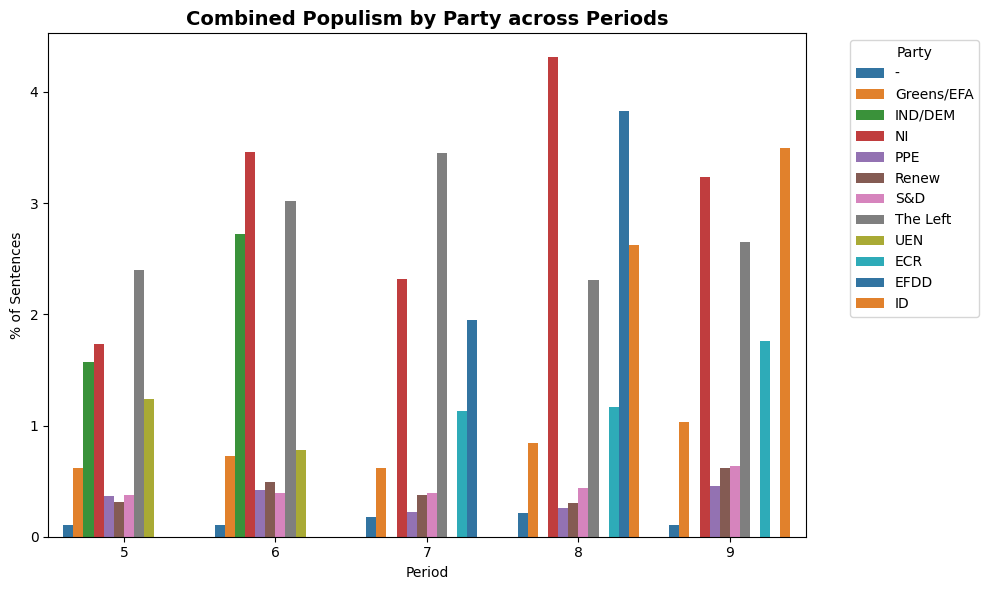

In [24]:
for dim_col, dim_name, *_ in dimensions[:4]:
    share_col = f'{dim_name}_share'
    
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=party_period,
        x='period',
        y=share_col,
        hue='party',
        palette=line_palette
    )
    plt.title(f'{dim_name.replace("_", " ").title()} by Party across Periods', fontsize=14, fontweight='bold')
    plt.ylabel('% of Sentences')
    plt.xlabel('Period')
    plt.legend(title='Party', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    #plt.savefig(f'../outputs/bar_charts/{dim_name}_party_period.png', dpi=300, bbox_inches='tight')
    plt.show()